# Volatility Smile Analysis
**For MATH 468 - Financial Stochastic Analysis | Spring 2026**

**Presenter: Ruiqian Su, rus322@lehigh.edu, PhD student in applied mathematics (probability and statistics track)**

Outline:
1. Fetch real options data
2. Compute implied volatility by inverting Black-Scholes numerically
3. Construct and compare volatility smiles across maturities
4. Run statistical diagnostics on returns to explain why the smile exists


In [18]:
import numpy as np
import yfinance as yf

from data import get_dividend_yield, get_options_chain, list_expiries
from iv_solver import compute_iv_surface, time_to_expiry_years
from visualizer import (
    plot_return_diagnostics,
    plot_smile,
    plot_smile_comparison,
    plot_vol_surface_3d,
)

TICKER = "AAPL"

## 1. Available Expiry Dates

In [19]:
expiries = list_expiries(TICKER)
print(f"Available expiries for {TICKER}:")
for e in expiries[:10]:
    print(f"  {e}")

Available expiries for AAPL:
  2026-05-13
  2026-05-15
  2026-05-18
  2026-05-20
  2026-05-22
  2026-05-29
  2026-06-05
  2026-06-12
  2026-06-18
  2026-06-26


## 2. Fetch Data and Compute Implied Volatility

In [20]:
from datetime import date, datetime

ANALYSIS_MIN_DAYS = 7
COMPARISON_MIN_DAYS = 7
MIN_VALID_IV_POINTS = 6

def days_to_expiry(expiry_str: str) -> int:
    return (datetime.strptime(expiry_str, "%Y-%m-%d").date() - date.today()).days

analysis_candidates = [e for e in expiries if days_to_expiry(e) >= ANALYSIS_MIN_DAYS]
expiry = analysis_candidates[0] if analysis_candidates else expiries[0]
calls, S0, r, expiry = get_options_chain(TICKER, expiry)
q = get_dividend_yield(TICKER)

print(f"Spot price S0 = {S0:.2f}")
print(f"Risk-free rate r = {r:.4f}")
print(f"Dividend yield q = {q:.4f}")
print(f"Expiry: {expiry} ({days_to_expiry(expiry)} days out)")
print(f"Options fetched: {len(calls)}")
calls.head(10)

Spot price S0 = 298.87
Risk-free rate r = 0.0360
Dividend yield q = 0.3700
Expiry: 2026-05-20 (7 days out)
Options fetched: 27


,strike,lastPrice,bid,ask,mid,volume,openInterest
0,245.0,48.00,52.50,56.00,54.250,NaN,1
1,250.0,41.97,47.65,51.10,49.375,1.0,3
2,255.0,37.25,42.60,45.65,44.125,1.0,1
3,262.5,30.10,35.25,38.65,36.950,NaN,1
4,265.0,25.93,33.45,35.75,34.600,61.0,62
5,270.0,28.30,28.25,31.20,29.725,2.0,2
6,272.5,27.01,25.30,28.70,27.000,2.0,18
7,275.0,18.29,22.90,25.85,24.375,1.0,15
8,277.5,23.18,20.80,23.80,22.300,121.0,75
9,280.0,15.30,18.45,20.95,19.700,6.0,38


## Black-Scholes-Merton Formula with Continuous Dividend Yield

The standard Black-Scholes model (Black & Scholes, 1973) assumes the underlying asset pays **no dividends**. However, SPY (S&P 500 ETF) distributes quarterly dividends with an annual yield of approximately 1.2–1.5%. Ignoring this would introduce a systematic bias in our implied volatility estimates.

We therefore use the **Black-Scholes-Merton extension** (Merton, 1973), which incorporates a continuous dividend yield $q$:

$$d_{\pm} = \frac{\ln(S_0/K) + (r - q \pm \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

$$F_0 = S_0 e^{-qT}\Phi(d_+) - Ke^{-rT}\Phi(d_-)$$

The intuition is straightforward: a dividend-paying stock is worth less than a non-dividend-paying one, because part of the value "leaks out" as cash to shareholders. This is captured by discounting the spot price by $e^{-qT}$.

**References**
- Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3), 637–654.
- Merton, R. C. (1973). Theory of rational option pricing. *Bell Journal of Economics and Management Science*, 4(1), 141–183.

In [7]:
df_iv = compute_iv_surface(calls, S0, r, expiry, q=q)
print(f"Options with valid IV: {len(df_iv)}")
df_iv[["strike", "mid", "iv", "moneyness", "log_moneyness"]].head(10)

Options with valid IV: 27


,strike,mid,iv,moneyness,log_moneyness
0,245.0,54.250,1.146863,0.819754,-0.198750
1,250.0,49.375,1.072886,0.836484,-0.178548
2,255.0,44.125,0.949997,0.853214,-0.158745
3,262.5,36.950,0.854081,0.878308,-0.129758
4,265.0,34.600,0.824542,0.886673,-0.120279
5,270.0,29.725,0.743910,0.903403,-0.101587
6,272.5,27.000,0.674776,0.911768,-0.092370
7,275.0,24.375,0.615930,0.920133,-0.083238
8,277.5,22.300,0.607199,0.928497,-0.074188
9,280.0,19.700,0.549556,0.936862,-0.065219


## 3. The Volatility Smile

If Black-Scholes were correct, this would be a **flat horizontal line**.  
Below we use **strike** on the x-axis for the main smile plot, and keep a **log-moneyness** version as a normalized comparison view.


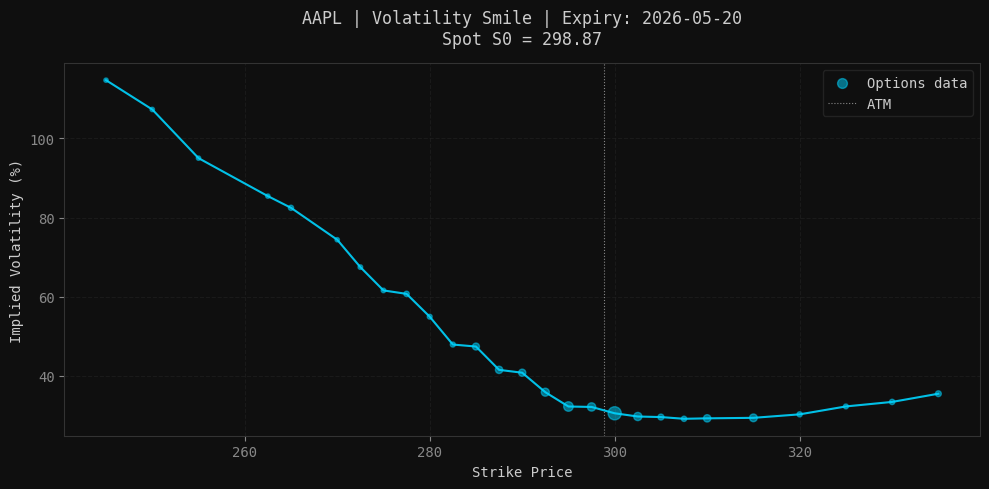

In [8]:
plot_smile(df_iv, TICKER, expiry, S0, x_axis="strike",
           save_path="results/figures/smile_single.png")

For comparison, here is the same smile plotted against **log-moneyness**.


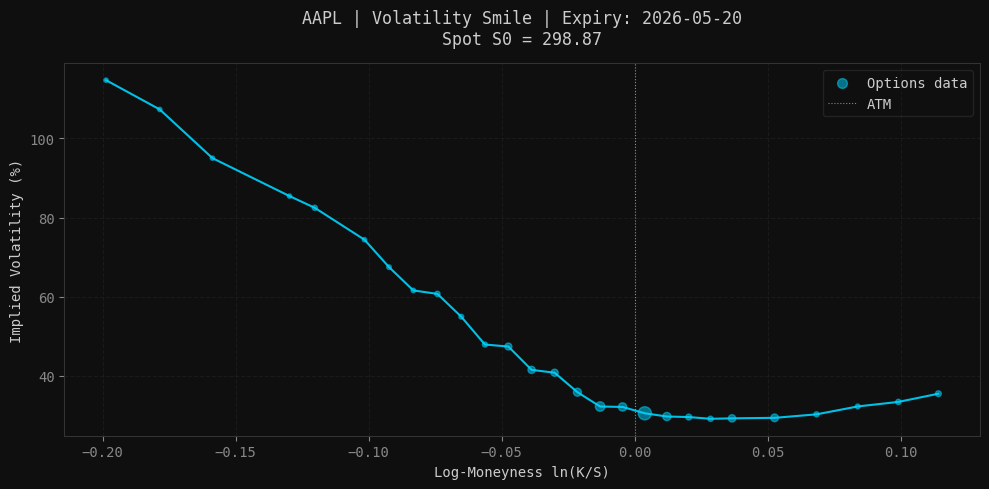

In [9]:
plot_smile(df_iv, TICKER, expiry, S0, x_axis="log_moneyness",
           save_path="results/figures/smile_single_log_moneyness.png")

## 4. How the Smile Changes Across Maturities

For the same underlying, we compare maturities against **strike** so the smile stays on the original option-market x-axis.


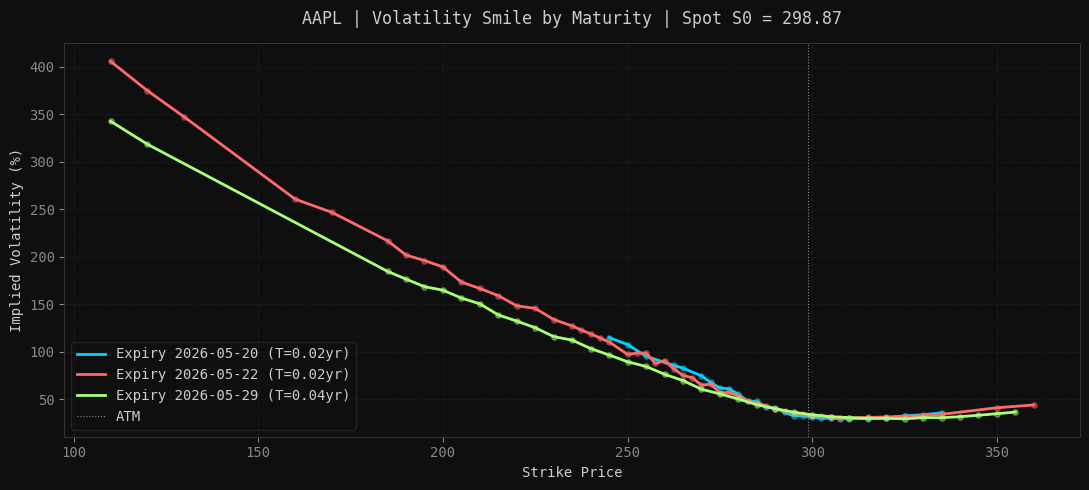

In [21]:
candidate_expiries = [e for e in expiries if days_to_expiry(e) >= ANALYSIS_MIN_DAYS]
selected_expiries = candidate_expiries[:3]
if len(selected_expiries) < 3:
    selected_expiries = expiries[:3]

dfs, labels, maturities = [], [], []

for exp in selected_expiries:
    try:
        c, _, _, e = get_options_chain(TICKER, exp)
        df = compute_iv_surface(c, S0, r, e, q=q)
        if len(df) > 5:
            T = time_to_expiry_years(e)
            dfs.append(df)
            labels.append(f"Expiry {e} (T={T:.2f}yr)")
            maturities.append(T)
    except Exception as ex:
        print(f"Skipping {exp}: {ex}")

plot_smile_comparison(dfs, labels, TICKER, S0, x_axis="strike",
                      save_path="results/figures/smile_comparison.png")

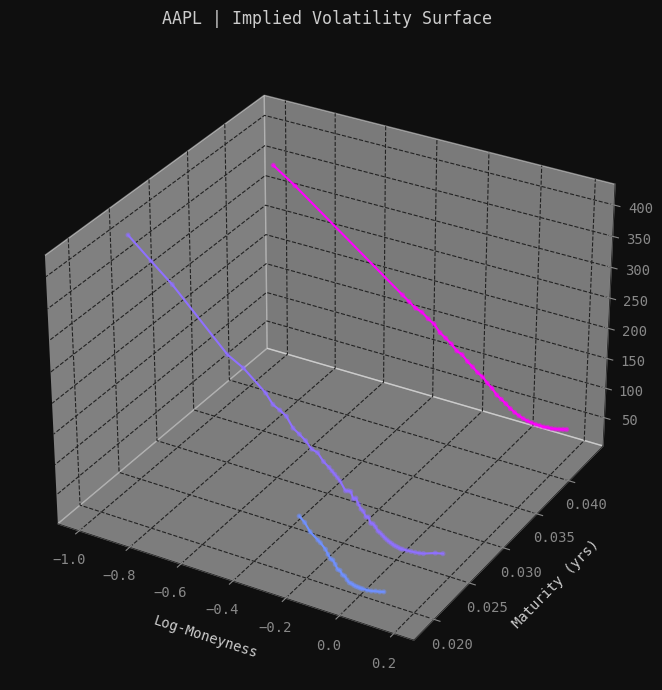

In [11]:
plot_vol_surface_3d(dfs, maturities, TICKER,
                    save_path="results/figures/vol_surface_3d.png")

## 5. Comparing Different Stocks at a Common Expiry

To compare different underlyings fairly, we normalize strike into **log-moneyness** and choose a shared expiry that is far enough from maturity to avoid same-day noise and still gives enough valid IV points for every ticker.


In [23]:
COMPARISON_TICKERS = ["SPY", "AAPL", "TSLA"]

expiry_sets = [set(list_expiries(ticker)) for ticker in COMPARISON_TICKERS]
common_expiries = sorted(set.intersection(*expiry_sets))
if not common_expiries:
    raise ValueError(f"No common expiry found for {COMPARISON_TICKERS}")

comparison_candidates = [e for e in common_expiries if days_to_expiry(e) >= COMPARISON_MIN_DAYS]
if not comparison_candidates:
    comparison_candidates = common_expiries

print("Candidate common expiries:")
for e in comparison_candidates[:10]:
    print(f"  {e} ({days_to_expiry(e)} days out)")

Candidate common expiries:
  2026-05-20 (7 days out)
  2026-05-22 (9 days out)
  2026-05-29 (16 days out)
  2026-06-05 (23 days out)
  2026-06-12 (30 days out)
  2026-06-18 (36 days out)
  2026-06-26 (44 days out)
  2026-07-17 (65 days out)
  2026-08-21 (100 days out)
  2026-09-18 (128 days out)


In [24]:
stock_dfs, stock_labels, stock_summary = [], [], []
comparison_expiry = None

for exp in comparison_candidates:
    tmp_dfs, tmp_labels, tmp_summary = [], [], []

    for ticker in COMPARISON_TICKERS:
        calls_i, S_i, r_i, exp_i = get_options_chain(ticker, exp)
        q_i = get_dividend_yield(ticker)
        df_i = compute_iv_surface(calls_i, S_i, r_i, exp_i, q=q_i)
        if len(df_i) < MIN_VALID_IV_POINTS:
            print(f"Skipping expiry {exp}: {ticker} has only {len(df_i)} valid IV points")
            break

        tmp_dfs.append(df_i)
        tmp_labels.append(f"{ticker}  (S0={S_i:.2f})")

        atm_idx = (df_i["log_moneyness"].abs()).idxmin()
        atm_iv = df_i.loc[atm_idx, "iv"] * 100
        left_wing = df_i[df_i["log_moneyness"] < 0]["iv"].mean() * 100
        right_wing = df_i[df_i["log_moneyness"] > 0]["iv"].mean() * 100
        tmp_summary.append({
            "ticker": ticker,
            "spot": round(S_i, 2),
            "atm_iv_pct": round(float(atm_iv), 2),
            "left_wing_iv_pct": round(float(left_wing), 2),
            "right_wing_iv_pct": round(float(right_wing), 2),
        })
    else:
        comparison_expiry = exp
        stock_dfs, stock_labels, stock_summary = tmp_dfs, tmp_labels, tmp_summary
        break

if comparison_expiry is None:
    raise ValueError(
        f"No shared expiry produced at least {MIN_VALID_IV_POINTS} valid IV points for all tickers."
    )

print(f"Common expiry used for cross-stock comparison: {comparison_expiry}")

import pandas as pd
pd.DataFrame(stock_summary)

Common expiry used for cross-stock comparison: 2026-05-20


,ticker,spot,atm_iv_pct,left_wing_iv_pct,right_wing_iv_pct
0,SPY,742.31,14.12,22.26,14.10
1,AAPL,298.87,30.58,63.66,30.95
2,TSLA,445.27,49.19,59.73,59.07


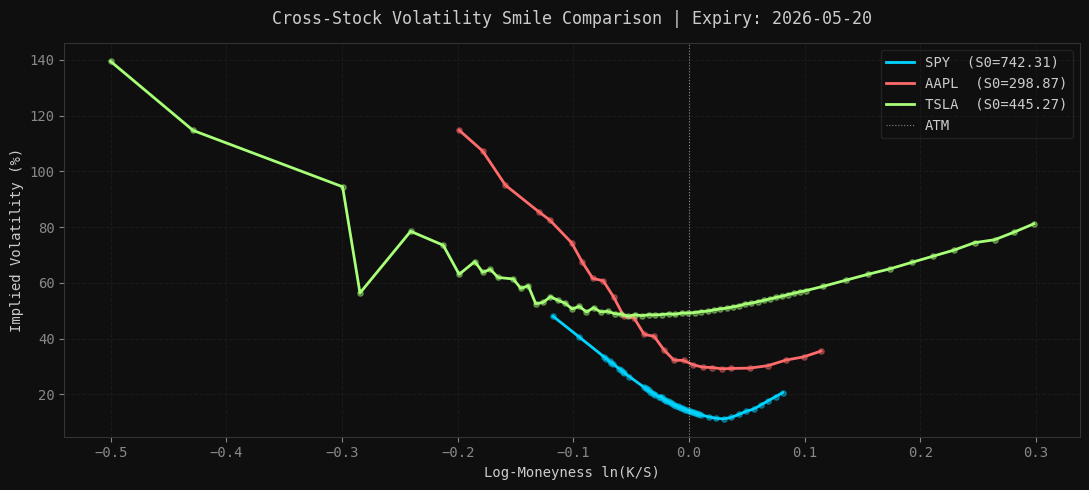

In [25]:
plot_smile_comparison(
    stock_dfs,
    stock_labels,
    "SPY / AAPL / TSLA",
    S=None,
    x_axis="log_moneyness",
    save_path="results/figures/smile_cross_stock.png",
    title=f"Cross-Stock Volatility Smile Comparison | Expiry: {comparison_expiry}",
)

## 6. Why Does the Smile Exist? Statistical Diagnostics

**Hypothesis**: the smile exists because volatility is **not constant**.
It clusters, spikes during market stress, and reverts over time — directly
violating Black-Scholes' core assumption.
The non-normal return distribution we observe (fat tails, skewness) is a
*consequence* of this time-varying volatility, not an independent cause.
The options market prices in this reality, producing the smile.


In [26]:
hist = yf.download(TICKER, period="5y", auto_adjust=True)
close = hist["Close"]

# yfinance may return Close as a one-column DataFrame instead of a Series.
if isinstance(close, pd.DataFrame):
    if TICKER in close.columns:
        close = close[TICKER]
    elif close.shape[1] == 1:
        close = close.iloc[:, 0]
    else:
        raise ValueError(f"Unexpected Close columns: {list(close.columns)}")

log_returns = np.log(close / close.shift(1)).dropna()

from scipy import stats
print(f"N observations : {len(log_returns)}")
print(f"Mean           : {float(log_returns.mean()):.6f}")
print(f"Std            : {float(log_returns.std()):.6f}")
print(f"Skewness       : {float(log_returns.skew()):.4f}  (negative = heavier left tail)")
print(f"Excess kurtosis: {float(log_returns.kurt()):.4f}  (positive = fatter tails than normal)")

jb_stat, jb_p = stats.jarque_bera(log_returns)
print(f"Jarque-Bera    : stat={float(jb_stat):.1f}  p-value={float(jb_p):.2e}  (p << 0.05 rejects normality)")

[*********************100%***********************]  1 of 1 completed

N observations : 1254
Mean           : 0.000700
Std            : 0.017235
Skewness       : 0.2509  (negative = heavier left tail)
Excess kurtosis: 5.9574  (positive = fatter tails than normal)
Jarque-Bera    : stat=1849.8  p-value=0.00e+00  (p << 0.05 rejects normality)


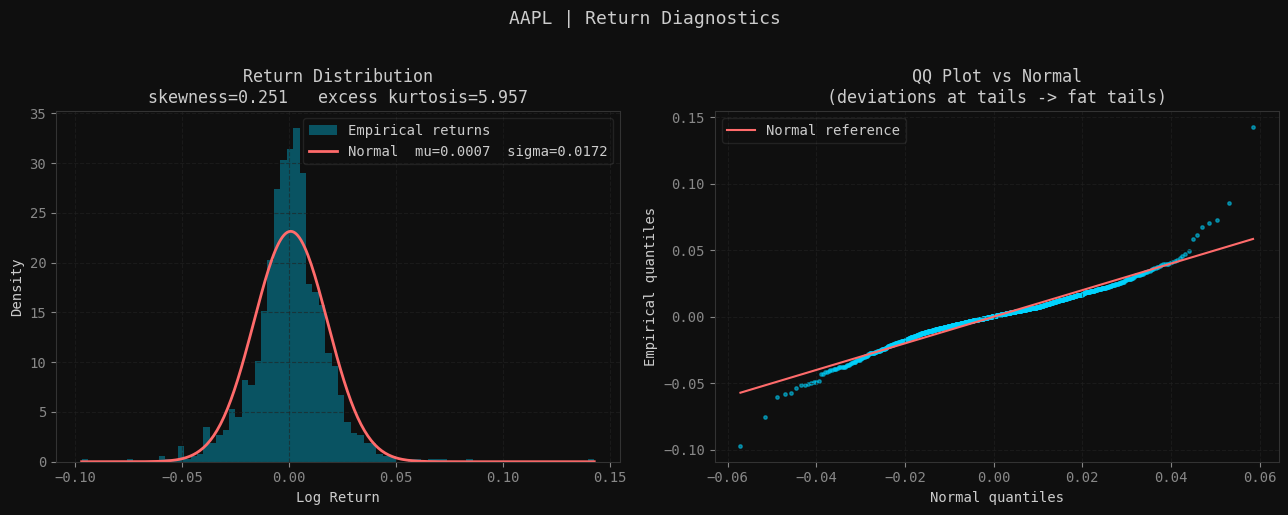

In [27]:
plot_return_diagnostics(log_returns, TICKER,
                        save_path="results/figures/return_diagnostics.png")

## 7. Key Conclusions

| Observation | Implication for volatility smile |
|---|---|
| Excess kurtosis (fat tails) | Wing IV is elevated relative to Black-Scholes predictions |
| Jarque-Bera rejects normality | Return distribution deviates from normality — a symptom of non-constant volatility |
| Skewness sign depends on the underlying and sample period | The smile/skew need not lean left for every stock |
| Smile flattening at longer maturities | Inferred from the maturity-comparison plot, not the return diagnostics |

**Bottom line**: the volatility smile is not a market anomaly. The root cause is that
volatility is not constant — it clusters, mean-reverts, and responds to market events.
The non-normal return distribution we observe is a *consequence* of this, not an
independent cause. The smile is the market's rational repricing of options once this
reality is acknowledged.